# Issues we need to account for:
    [python for MRI analysis DAY1](https://www.youtube.com/watch?v=gMuxB18Cr0o) -- for fMRI especially
	- we have whole head images, we just want the brain
	- fMRI image and T1 image are not aligned
	- fMRI is distorted due to changing magnetic field in some area of brain
	- Participants move in scanners, fMRI image isn't aligned to it self
	- Movement actually influences the fMRI signal, we want brain signals not motion signals.
	- All subject aren't aligned to each other, need to warp images to a template (we need some sort of normalisation)

pre-processing for T1

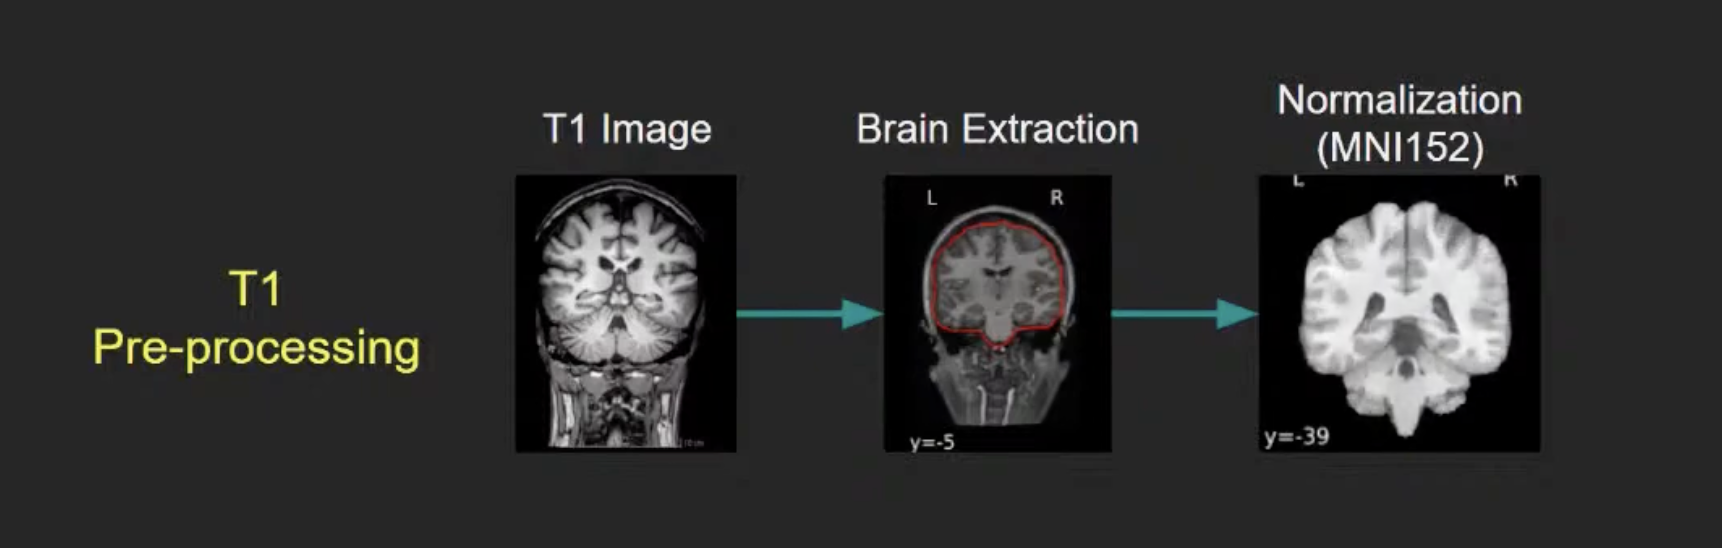

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-066/anat/sub-032633_ses-066_run-1_T1w.nii.gz"

# fmri_path = "../data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
img = nib.load(fmri_path)
data = img.get_fdata()
affine = img.affine

print("Shape:", data.shape)
print("Voxel size (mm):", img.header.get_zooms()[:3])

Shape: (176, 256, 256)
Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [3]:
print("Current orientation:", aff2axcodes(affine))  # 例如 ('L', 'I', 'P')
print("Is standard RAS+?", aff2axcodes(affine) == ('R', 'A', 'S'))

NameError: name 'aff2axcodes' is not defined

# N4 correction

In [1]:
import SimpleITK as sitk
import nibabel as nib
import numpy as np

# 1. Load the image using SimpleITK
# (SimpleITK handles the Affine/Spacing automatically)
fmri_path = "../data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
input_image = sitk.ReadImage(fmri_path)

input_image_float = sitk.Cast(input_image, sitk.sitkFloat32)

# 2. Execute N4 Bias Field Correction
# This will 'flatten' the lighting of the brain
mask_for_n4 = sitk.OtsuThreshold(input_image_float, 0, 1, 200) # Simple internal mask for N4
corrector = sitk.N4BiasFieldCorrectionImageFilter()
corrected_image = corrector.Execute(input_image_float, mask_for_n4)

# 3. Convert back to Numpy to see the difference in Histogram
original_data = sitk.GetArrayFromImage(input_image_float)
corrected_data = sitk.GetArrayFromImage(corrected_image)

# # 4. Save the 'clean' image for the next steps
# sitk.WriteImage(corrected_image, 'preprocessed_t1.nii.gz')

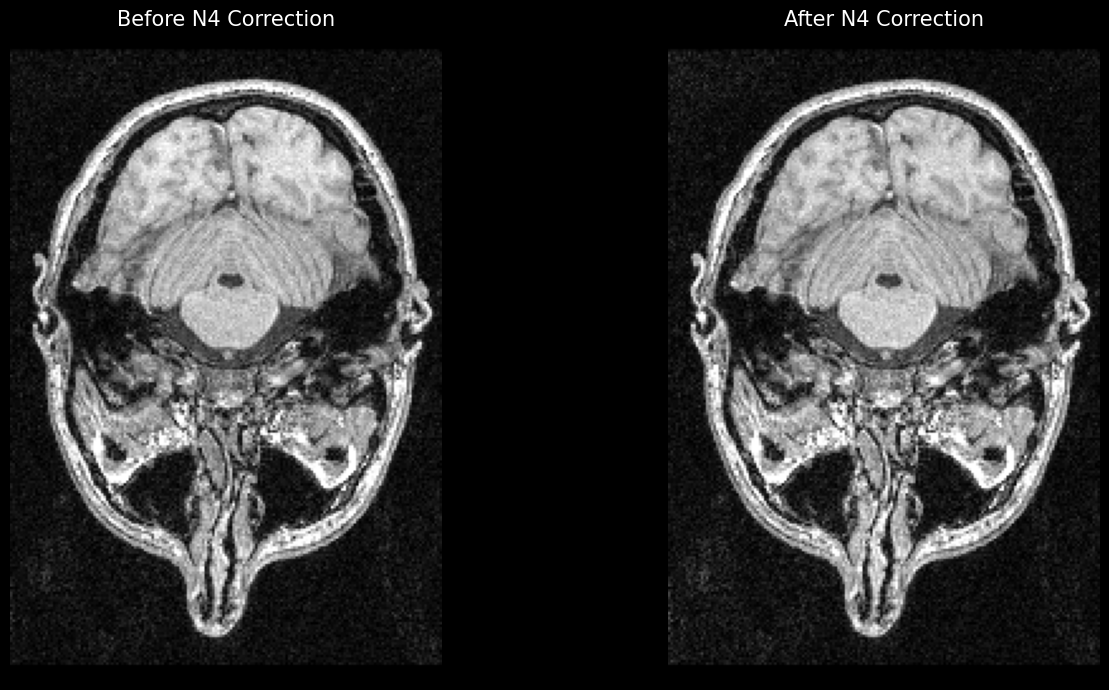

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Select a middle slice
slice_idx = original_data.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor='black')

# Use the same vmin/vmax for both to ensure a fair comparison
# We'll use the 2nd and 98th percentile of the original data to set the scale
vmin, vmax = np.percentile(original_data, [2, 98])

axes[0].imshow(original_data[slice_idx, :, :], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title("Before N4 Correction", color='white', fontsize=15)
axes[0].axis('off')

axes[1].imshow(corrected_data[slice_idx, :, :], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title("After N4 Correction", color='white', fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

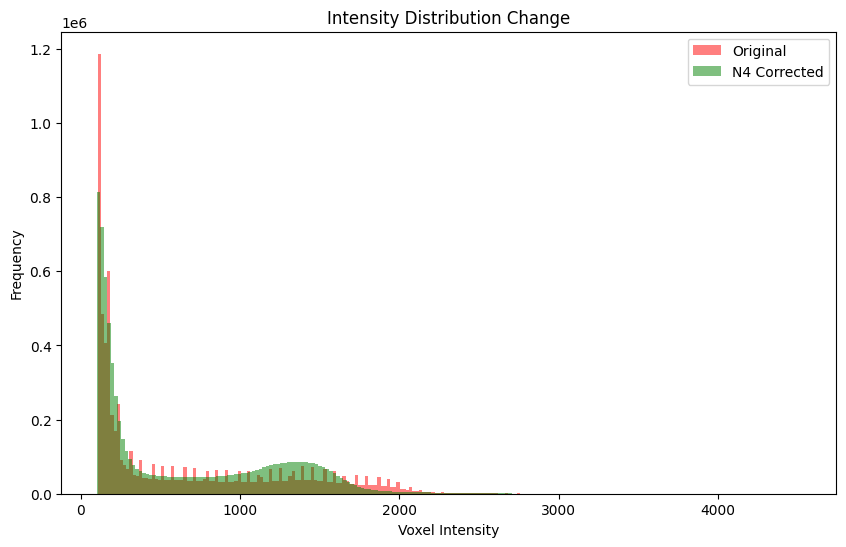

In [3]:
plt.figure(figsize=(10, 6))

# Filter out background (zeros/noise) to see the brain peaks clearly
# Adjust 'threshold' based on your previous histogram (e.g., > 100)
threshold = 100
orig_pixels = original_data[original_data > threshold].ravel()
corr_pixels = corrected_data[corrected_data > threshold].ravel()

plt.hist(orig_pixels, bins=200, alpha=0.5, label='Original', color='red')
plt.hist(corr_pixels, bins=200, alpha=0.5, label='N4 Corrected', color='green')

plt.title("Intensity Distribution Change")
plt.xlabel("Voxel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

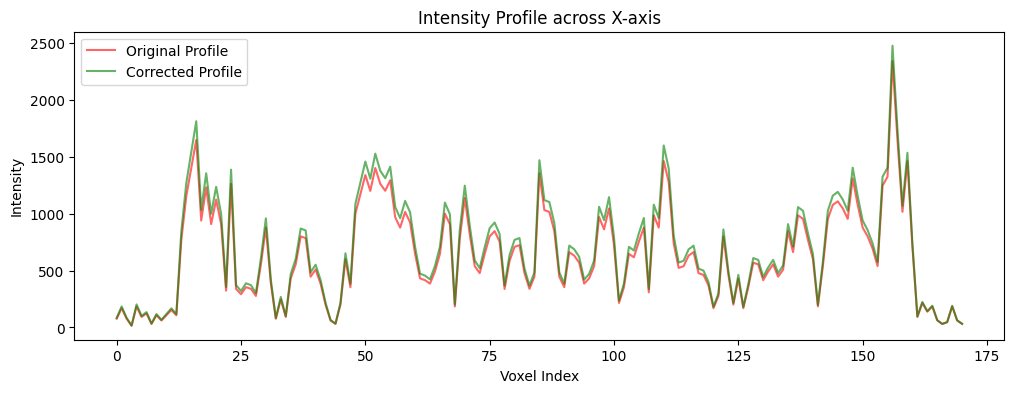

In [4]:
# Pick a row that goes through both hemispheres
row_idx = original_data.shape[1] // 2
line_orig = original_data[slice_idx, row_idx, :]
line_corr = corrected_data[slice_idx, row_idx, :]

plt.figure(figsize=(12, 4))
plt.plot(line_orig, label='Original Profile', color='red', alpha=0.6)
plt.plot(line_corr, label='Corrected Profile', color='green', alpha=0.6)
plt.title("Intensity Profile across X-axis")
plt.xlabel("Voxel Index")
plt.ylabel("Intensity")
plt.legend()
plt.show()

# Brain extraction

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [4]:
# Convert SimpleITK image back to Nibabel Nifti
corrected_data_arr = sitk.GetArrayFromImage(corrected_image)

# SimpleITK uses (z, y, x) order, Nibabel uses (x, y, z)
# We must transpose back to match your original Affine
corrected_data_arr = np.transpose(corrected_data_arr, (2, 1, 0))

# Create a new Nifti image using the original affine
corrected_nifti = nib.Nifti1Image(corrected_data_arr, img.affine)

NameError: name 'sitk' is not defined

In [5]:
from nilearn.masking import compute_brain_mask
from nilearn import plotting

# Compute mask on the 'clean' image
# 'opening=2' helps remove those small 'floating' noise pixels you saw earlier
brain_mask = compute_brain_mask(img, opening=2)

# Apply the mask to get the 'Brain-Only' image
from nilearn.image import math_img
brain_only_img = math_img("img * mask", img=img, mask=brain_mask)

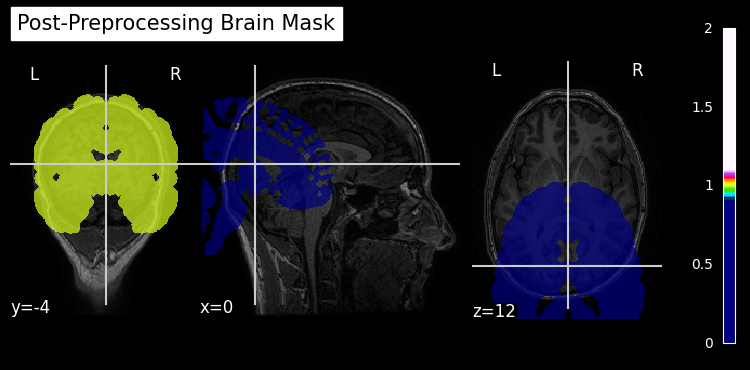

In [6]:
plotting.plot_roi(brain_mask, bg_img=img, 
                  title="Post-Preprocessing Brain Mask",
                  display_mode='ortho')
plotting.show()

In [7]:
from nilearn.masking import compute_multi_brain_mask
from nilearn.image import threshold_img
from nilearn.image import new_img_like

# Create a version of the image where extreme outliers are removed
# This helps the masking algorithm 'see' the brain peaks better
# img_clipped = threshold_img(img, threshold=20, copy=True) 
# Note: You can also manually clip: data[data > 2000] = 2000


mask = compute_brain_mask(img, opening=3) # 'opening' cleans up small noise pixels

# robust_mask = compute_multi_brain_mask(corrected_nifti)
perfect_alignment_mask = new_img_like(img, mask.get_fdata())
plotting.plot_roi(perfect_alignment_mask, bg_img=corrected_nifti, 
                  cut_coords=None, # This tells Nilearn to find the 'cut' automatically
                  display_mode='ortho', 
                  title="Auto-center Check")
plotting.show()


NameError: name 'corrected_nifti' is not defined

In [11]:
print(np.allclose(img.affine, brain_mask.affine))

True


## use compute_epi_mask

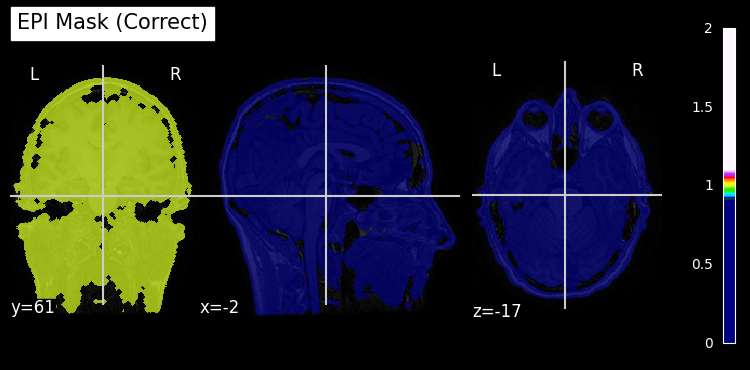

In [14]:
from nilearn.masking import compute_epi_mask
from nilearn import plotting
import matplotlib.pyplot as plt

# 使用 EPI 专用 mask 计算
brain_mask = compute_epi_mask(
    img,
    opening=2,          # 形态学开运算，去除小噪声
    exclude_zeros=True, # 忽略全零时间点
#     threshold=0.5       # 强度阈值（默认 0.5，可根据数据调整）
)

# 可视化验证
plotting.plot_roi(
    brain_mask, 
    bg_img=img,
    title="EPI Mask (Correct)",
    display_mode='ortho',
#     cmap='magma'
)
plt.show()

 Important: **compute_brain_mask** is designed for T1, and **compute_epi_mask** is designed for fMRI EPI image. But why this works better for T1?

In [9]:
# 1. 检查维度
print(f"Shape: {data.shape}")
# T1w: 通常是 3D (x, y, z)  如 (256, 256, 176)
# EPI: 通常是 4D (x, y, z, time) 如 (64, 64, 40, 300)

# 2. 检查脑脊液 (CSF) 信号强度
# 提取 ventricle 区域（近似坐标，需根据实际图像调整）
if data.ndim == 4:
    vol = data[..., 0]  # 取第一帧
else:
    vol = data

# 粗略估计 CSF 强度（侧脑室中心区域）
csf_roi = vol[90:110, 80:100, 80:100].mean()
brain_roi = vol[100:120, 100:120, 70:90].mean()  # 灰质区域

print(f"CSF intensity: {csf_roi:.2f}")
print(f"Brain intensity: {brain_roi:.2f}")
print(f"CSF/Brain ratio: {csf_roi/brain_roi:.2f}")

Shape: (176, 256, 256)
CSF intensity: 1425.72
Brain intensity: 1152.38
CSF/Brain ratio: 1.24


In [12]:
brain_mask.shape

(176, 256, 256)

### visualization

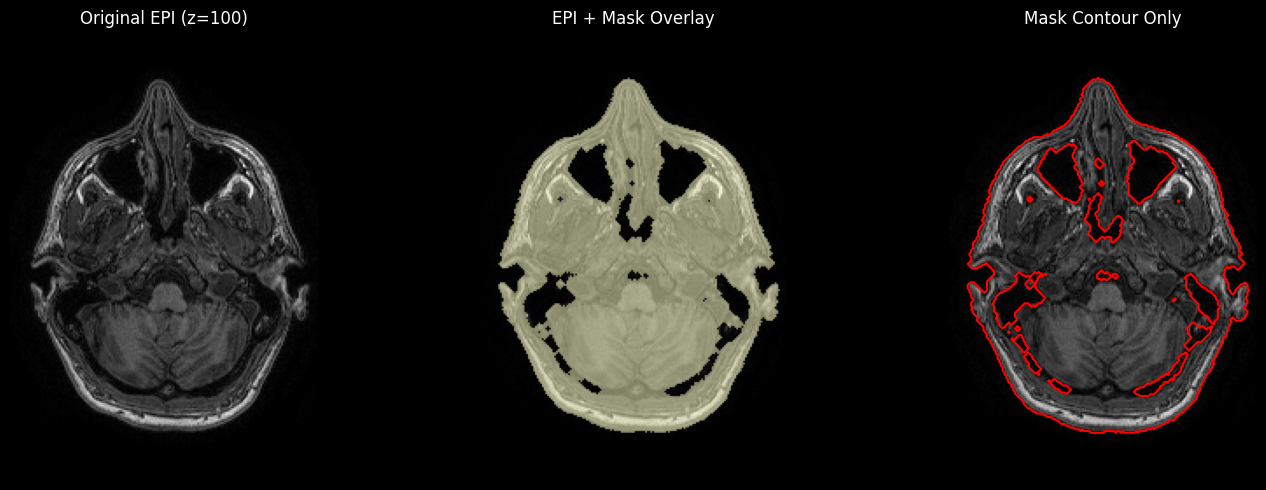

In [17]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
# epi_img = nib.load(corrected_nifti)
# mask_img = nib.load(brain_mask)

epi_data = img.get_fdata()
mask_data = brain_mask.get_fdata().astype(bool)

# 选择体素坐标（注意：NIfTI 顺序通常是 [x, y, z, t]）
slice_idx = 100  # 例如：z 轴第 30 层

# 提取 2D 切片（假设 4D 数据，取第 0 时间点）
if epi_data.ndim == 4:
    epi_slice = epi_data[:, :, slice_idx, 0].T  # .T 使图像方向符合 radiological convention
else:
    epi_slice = epi_data[:, :, slice_idx].T

mask_slice = mask_data[:, :, slice_idx].T

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 原始 EPI
axes[0].imshow(epi_slice, cmap='gray', origin='lower')
axes[0].set_title(f'Original EPI (z={slice_idx})')
axes[0].axis('off')

# Mask 叠加
axes[1].imshow(epi_slice, cmap='gray', origin='lower')
axes[1].imshow(mask_slice, cmap='magma', alpha=0.5, origin='lower')  # 半透明叠加
axes[1].set_title('EPI + Mask Overlay')
axes[1].axis('off')

# 仅 Mask 轮廓
axes[2].imshow(epi_slice, cmap='gray', origin='lower')
axes[2].contour(mask_slice, colors='red', linewidths=1.5)  # 仅显示轮廓
axes[2].set_title('Mask Contour Only')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## using other T1 image

dataset use: https://staging.openneuro.org/datasets/ds001037/versions/1.0.1  -- sub-01_ses-test_T1w.nii.gz

In [24]:
import nibabel as nib
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
fmri_path = "../data/sub-01_ses-test_T1w.nii.gz"

img_ds114 = nib.load(fmri_path)
data_ds114 = img_ds114.get_fdata()
affine_ds114 = img_ds114.affine

print("Shape:", data_ds114.shape)
print("Voxel size (mm):", img_ds114.header.get_zooms()[:3])

Shape: (256, 156, 256)
Voxel size (mm): (np.float32(1.0), np.float32(1.2993759), np.float32(1.0))


In [27]:
from nibabel.orientations import aff2axcodes

print("Current orientation:", aff2axcodes(affine_ds114))  # 例如 ('L', 'I', 'P')
print("Is standard RAS+?", aff2axcodes(affine_ds114) == ('R', 'A', 'S'))

Current orientation: ('R', 'A', 'S')
Is standard RAS+? True


In [31]:
# 1. 检查维度
print(f"Shape: {data_ds114.shape}")
# T1w: 通常是 3D (x, y, z)  如 (256, 256, 176)
# EPI: 通常是 4D (x, y, z, time) 如 (64, 64, 40, 300)

# 2. 检查脑脊液 (CSF) 信号强度
# 提取 ventricle 区域（近似坐标，需根据实际图像调整）
if data_ds114.ndim == 4:
    vol = data[..., 0]  # 取第一帧
else:
    vol = data

# 粗略估计 CSF 强度（侧脑室中心区域）
csf_roi = vol[90:110, 80:100, 80:100].mean()
brain_roi = vol[100:120, 100:120, 70:90].mean()  # 灰质区域

print(f"CSF intensity: {csf_roi:.2f}")
print(f"Brain intensity: {brain_roi:.2f}")
print(f"CSF/Brain ratio: {csf_roi/brain_roi:.2f}")

Shape: (256, 156, 256)
CSF intensity: 1425.72
Brain intensity: 1152.38
CSF/Brain ratio: 1.24


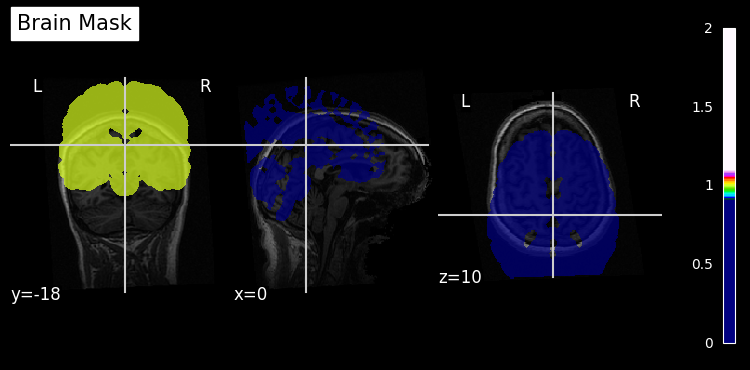

In [25]:
from nilearn.masking import compute_brain_mask
from nilearn import plotting

# Compute mask on the 'clean' image
# 'opening=2' helps remove those small 'floating' noise pixels you saw earlier
brain_mask = compute_brain_mask(img_ds114, opening=2)

plotting.plot_roi(brain_mask, bg_img=img_ds114, 
                  title="Brain Mask",
                  display_mode='ortho')
plotting.show()

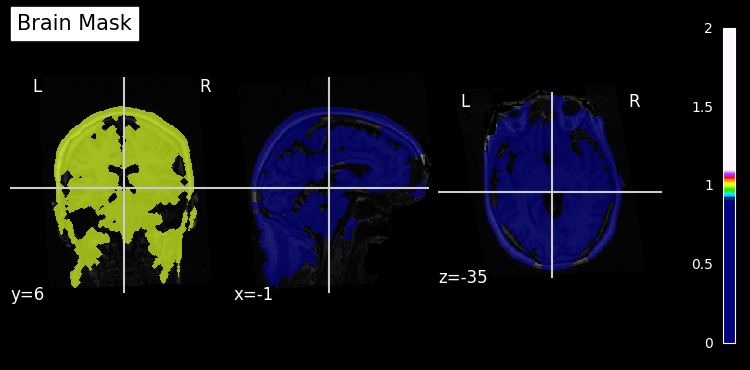

In [34]:
from nilearn.masking import compute_epi_mask
from nilearn import plotting

# Compute mask on the 'clean' image
# 'opening=2' helps remove those small 'floating' noise pixels you saw earlier
brain_mask = compute_epi_mask(img_ds114, opening=3)

plotting.plot_roi(brain_mask, bg_img=img_ds114, 
                  title="Brain Mask",
                  display_mode='ortho')
plotting.show()

In [29]:
# 计算两种掩膜
mask_brain = compute_brain_mask(img_ds114, opening=2)
mask_epi = compute_epi_mask(img_ds114, opening=2)

In [30]:
# 1. 检查 affine 一致性（关键！）
print("=== Affine 诊断 ===")
print("Original image affine:\n", affine_ds114)
print("\ncompute_brain_mask affine:\n", mask_brain.affine)
print("\ncompute_epi_mask affine:\n", mask_epi.affine)

print("\nAffine match (brain_mask vs original)?", 
      np.allclose(mask_brain.affine, affine_ds114, atol=1e-3))
print("Affine match (epi_mask vs original)?", 
      np.allclose(mask_epi.affine, affine_ds114, atol=1e-3))

=== Affine 诊断 ===
Original image affine:
 [[ 9.99131918e-01 -5.16291820e-02  1.25127016e-02 -1.25263863e+02]
 [ 4.07721959e-02  1.29202044e+00 -9.81179178e-02 -7.31330109e+01]
 [-8.54506902e-03  1.28044292e-01  9.95096147e-01 -1.77554291e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

compute_brain_mask affine:
 [[ 9.99131918e-01 -5.16291820e-02  1.25127016e-02 -1.25263863e+02]
 [ 4.07721959e-02  1.29202044e+00 -9.81179178e-02 -7.31330109e+01]
 [-8.54506902e-03  1.28044292e-01  9.95096147e-01 -1.77554291e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

compute_epi_mask affine:
 [[ 9.99131918e-01 -5.16291820e-02  1.25127016e-02 -1.25263863e+02]
 [ 4.07721959e-02  1.29202044e+00 -9.81179178e-02 -7.31330109e+01]
 [-8.54506902e-03  1.28044292e-01  9.95096147e-01 -1.77554291e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Affine match (brain_mask vs original)? True
Affine match (epi_mask vs original)? True


# to MNI152 template space

In [3]:
from nilearn.datasets import load_mni152_template

mni_template = load_mni152_template(resolution=1)  # 1mm MNI152
mni_template

In [7]:
import ants

t1_nib = img
t1_ants = ants.from_numpy(img.get_fdata())
mni_ants = ants.from_numpy(mni_template.get_fdata())

In [8]:
registration = ants.registration(
    fixed=mni_ants,        # 目标空间（MNI）
    moving=t1_ants,        # 你的T1
    type_of_transform='SyN'  # 非线性配准（科研标准）
)


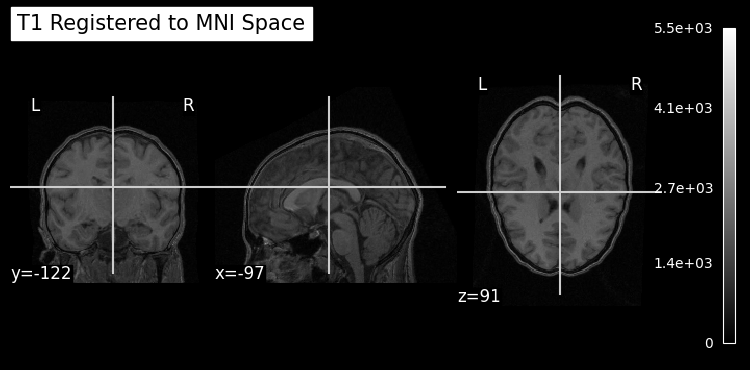

In [15]:
t1_mni_ants = registration['warpedmovout']
# t1_mni_nib = t1_mni_ants.to_nibabel()
t1_mni_ants.to_filename('temp.nii.gz')
t1_mni_nib = nib.load('temp.nii.gz')

from nilearn import plotting
plotting.plot_anat(t1_mni_nib, title="T1 Registered to MNI Space")
plotting.show()


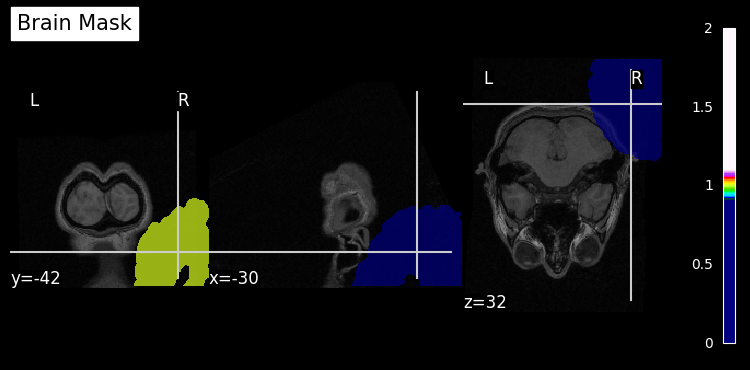

In [23]:
from nilearn.masking import compute_brain_mask

mask = compute_brain_mask(t1_mni_nib)

plotting.plot_roi(mask, bg_img=t1_mni_nib, title="Brain Mask")
plotting.show()

In [22]:
mask.get_fdata().shape

(197, 233, 189)

In [26]:
t1_mni_nib.get_fdata().shape

(197, 233, 189)

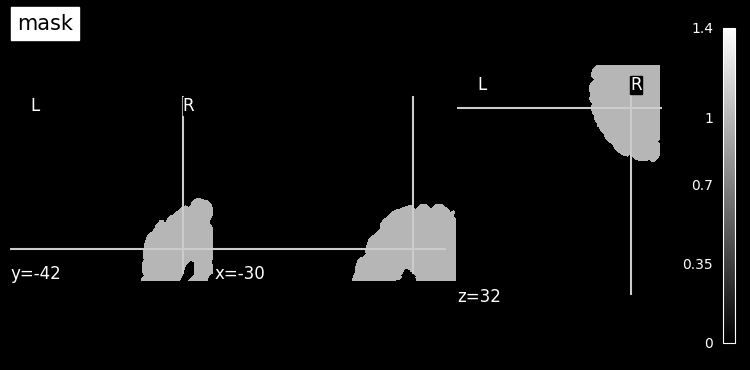

In [28]:
plotting.plot_anat(mask, title="mask")
plotting.show()